In [62]:
import tensorflow as tf
from keras.src.layers import Dropout
from tensorflow.keras import layers
import tensorboard as tb
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import SplineTransformer
import glob
import os

pjm_hourly_est = pd.read_csv('pjm_hourly_est.csv')

print(pjm_hourly_est.head())


              Datetime  AEP  COMED  DAYTON  DEOK  DOM  DUQ  EKPC  FE  NI  \
0  1998-12-31 01:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
1  1998-12-31 02:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
2  1998-12-31 03:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
3  1998-12-31 04:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
4  1998-12-31 05:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   

   PJME  PJMW  PJM_Load  
0   NaN   NaN   29309.0  
1   NaN   NaN   28236.0  
2   NaN   NaN   27692.0  
3   NaN   NaN   27596.0  
4   NaN   NaN   27888.0  


              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0


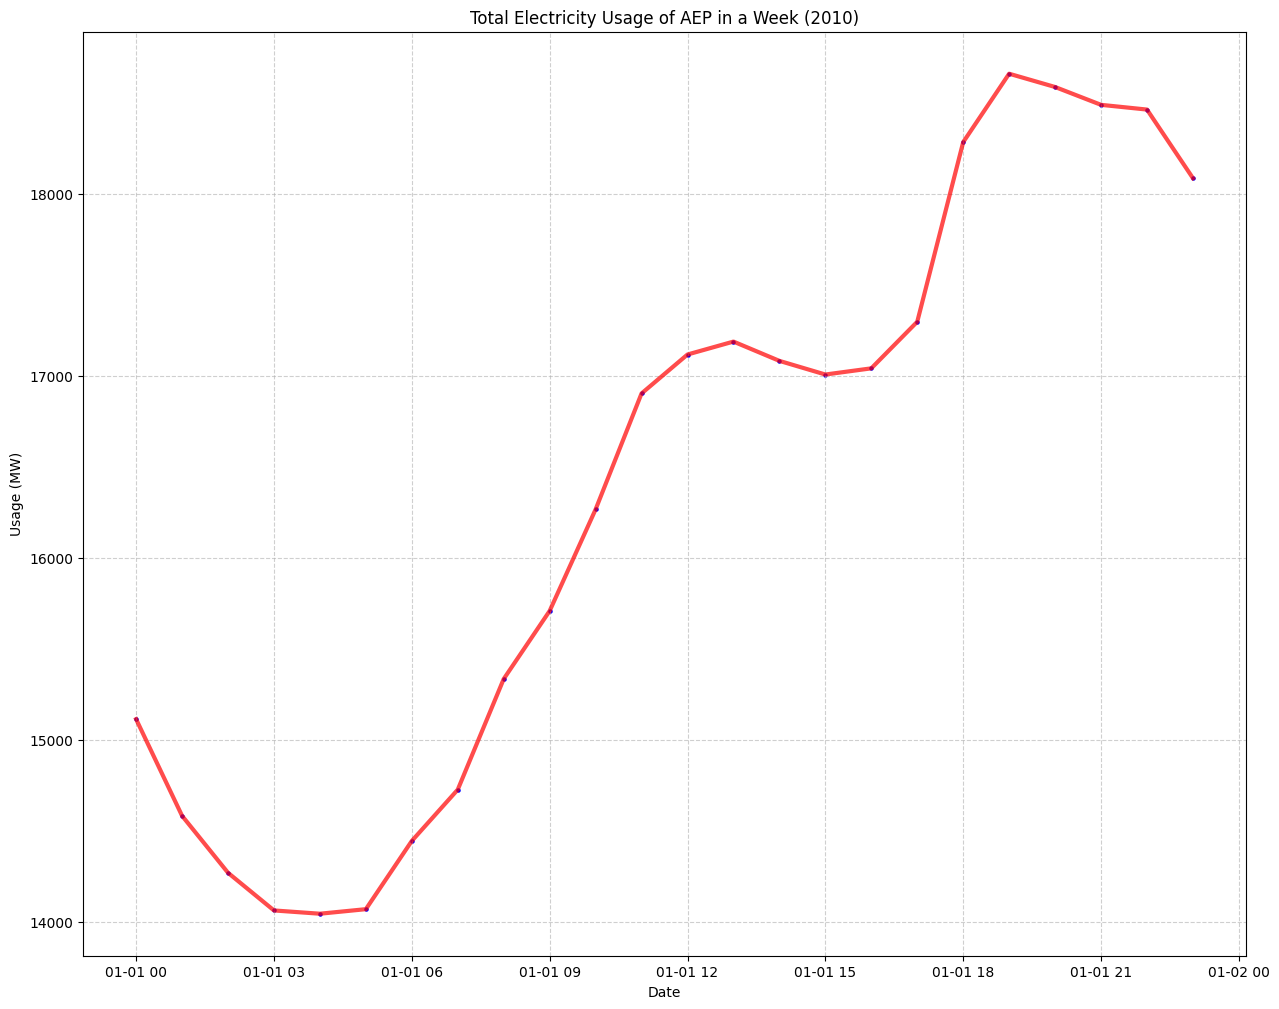

In [63]:
import matplotlib.pyplot as plt

pjm_hourly_AEP = pd.read_csv('electricity-data/AEP_hourly.csv')

print(pjm_hourly_AEP.head())

test_data = pjm_hourly_AEP.copy()
numeric_cols = test_data.select_dtypes(include=[np.number]).columns

test_data[numeric_cols] = test_data[numeric_cols].fillna(0)
test_data['total_usage'] = test_data[numeric_cols].sum(axis=1, skipna=True)

test_data = test_data[['Datetime', 'total_usage']]


start_datetime = pd.to_datetime('2010-01-01 00:00:00')
end_datetime = pd.to_datetime('2010-01-01 23:00:00')

format_string = "%Y-%m-%d %H:%M:%S"

test_data['Datetime'] = pd.to_datetime(test_data['Datetime'], format='%Y-%m-%d %H:%M:%S')

mask = (test_data['Datetime'] >= start_datetime) & (test_data['Datetime'] <= end_datetime)
plot_data = test_data.loc[mask]

plt.figure(figsize=(15, 12))

plot_data = plot_data.sort_values(by='Datetime')


# 2. Draw the raw points (the "dots")
plt.scatter(plot_data['Datetime'], plot_data['total_usage'], color='blue', s=5, alpha=1)

# 3. Draw the trend (the "line")
# Because it's sorted by Datetime, the line will move smoothly from left to right
plt.plot(plot_data['Datetime'], plot_data['total_usage'], color='red', linewidth=3, alpha=0.7)



#axis/format of plot
plt.title('Total Electricity Usage of AEP in a Week (2010)')
plt.xlabel('Date')
plt.ylabel('Usage (MW)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

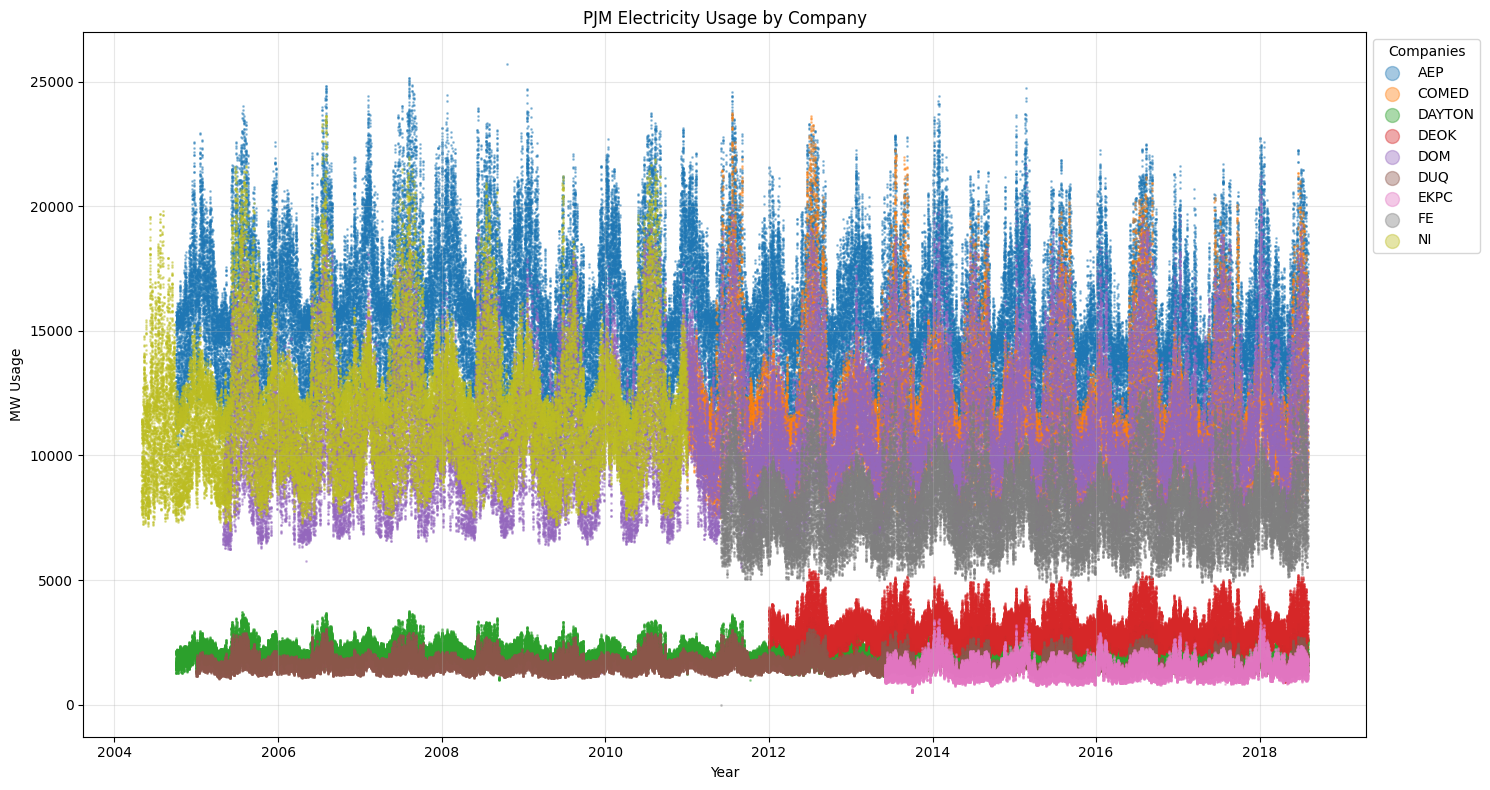

In [64]:
# Get a list of all CSV files in your directory
folder_path = 'electricity-data/*.csv'
files = glob.glob(folder_path)

all_data = []

for file in files:
    # Read the CSV
    df = pd.read_csv(file)
    
    # Standardize column names (PJM files often use the company name as the MW column)
    # This renames whatever the second column is to 'total_usage'
    df.columns = ['Datetime', 'total_usage']
    
    base_name = os.path.basename(file)
    # Extract company name from filename (e.g., "AEP.csv" -> "AEP")
    company_name = base_name.split('_')[0]
    df['Company'] = company_name
    
    # Convert to datetime
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    
    all_data.append(df)

# Combine everything into one giant dataframe
combined_df = pd.concat(all_data, ignore_index=True)




plt.figure(figsize=(15, 8))

# 1. Get the list of unique company names from your combined dataframe
companies = combined_df['Company'].unique()

# 2. Loop through each company and plot them separately
for company in companies:
    # Filter the dataframe for just this company
    subset = combined_df[combined_df['Company'] == company]
    
    # Plot the subset. Matplotlib will automatically cycle colors for each call.
    plt.scatter(subset['Datetime'], 
                subset['total_usage'], 
                s=1,           # Small points so they don't overlap too much
                alpha=0.4,     # Transparency to see density
                label=company) # This label is what the legend uses

# 3. Add the legend so you can tell which color is which
# We place it outside the plot (bbox_to_anchor) so it doesn't cover the data
plt.legend(markerscale=10, title="Companies", loc='upper left', bbox_to_anchor=(1, 1))

plt.title('PJM Electricity Usage by Company')
plt.xlabel('Year')
plt.ylabel('MW Usage')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

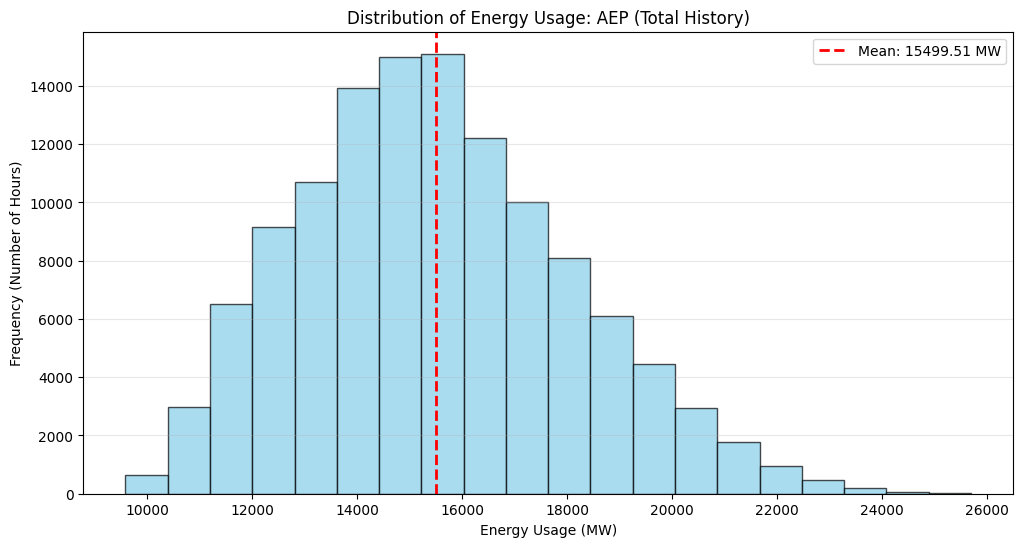

In [65]:
#histogram of energy use

# 1. Load the specific file
# Adjust the path if your folder structure is different
df_aep = pd.read_csv('electricity-data/AEP_hourly.csv')
df_aep.columns = ['Datetime', 'total_usage']

# 2. Create the Histogram
plt.figure(figsize=(12, 6))

# 'bins' determines how many bars are shown. 50-100 is usually good for this dataset.
plt.hist(df_aep['total_usage'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# 3. Formatting
plt.title('Distribution of Energy Usage: AEP (Total History)')
plt.xlabel('Energy Usage (MW)')
plt.ylabel('Frequency (Number of Hours)')
plt.grid(axis='y', alpha=0.3)

# Optional: Add a line for the average (Mean) usage
mean_usage = df_aep['total_usage'].mean()
plt.axvline(mean_usage, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_usage:.2f} MW')
plt.legend()

plt.show()

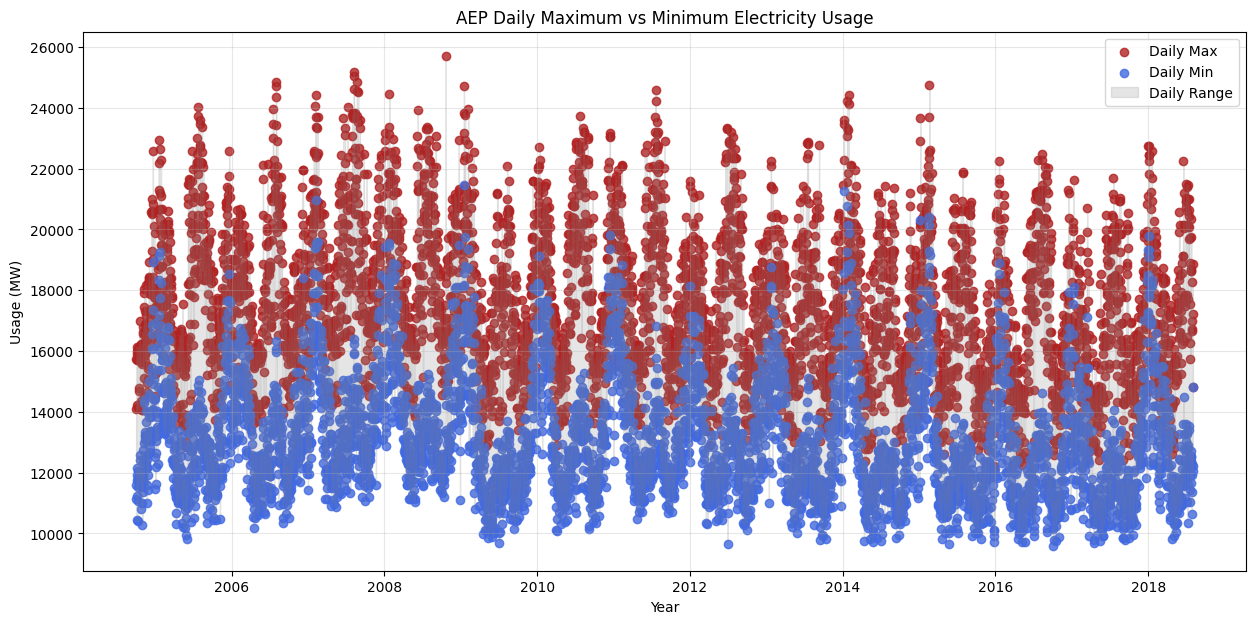

IQR Upper Bound: 22555.00
Number of outliers detected: 667


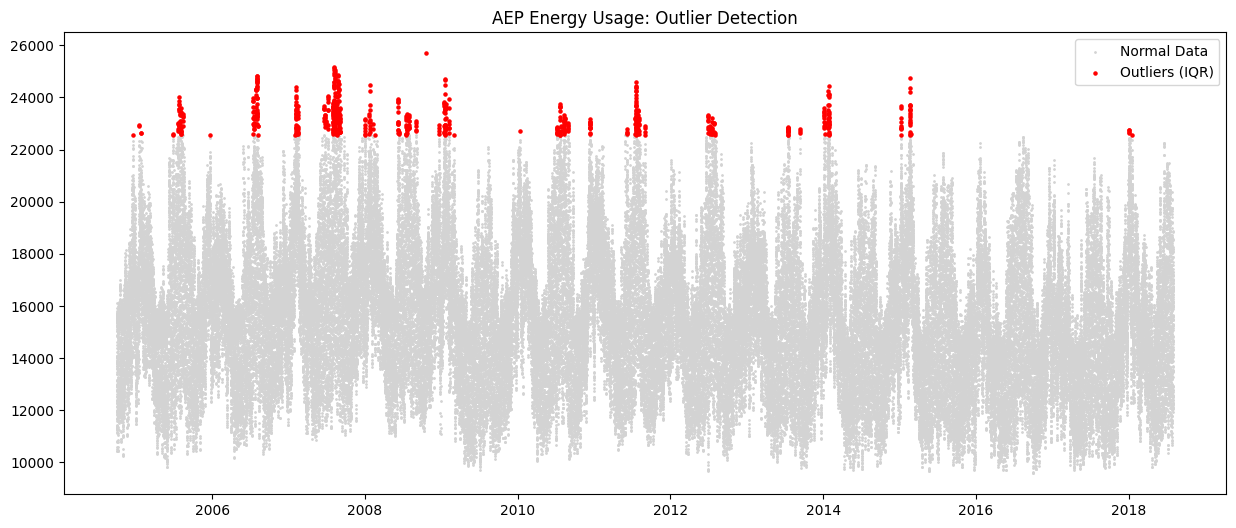

In [66]:
#Max and Min energy for one day

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and prepare the data
df_aep = pd.read_csv('electricity-data/AEP_hourly.csv')
df_aep.columns = ['Datetime', 'total_usage']
df_aep['Datetime'] = pd.to_datetime(df_aep['Datetime'])

# 2. Set Datetime as index (required for resampling)
df_aep = df_aep.set_index('Datetime')

# 3. Resample to find Daily Max and Daily Min
daily_max = df_aep['total_usage'].resample('D').max()
daily_min = df_aep['total_usage'].resample('D').min()

# 4. Plotting
plt.figure(figsize=(15, 7))

# Plotting Max as a red line and Min as a blue line
plt.scatter(daily_max.index, daily_max, label='Daily Max', color='firebrick', linewidth=1, alpha=0.8)
plt.scatter(daily_min.index, daily_min, label='Daily Min', color='royalblue', linewidth=1, alpha=0.8)

# Optional: Fill the area between them to show the "demand envelope"
plt.fill_between(daily_max.index, daily_min, daily_max, color='gray', alpha=0.2, label='Daily Range')

# Formatting
plt.title('AEP Daily Maximum vs Minimum Electricity Usage')
plt.xlabel('Year')
plt.ylabel('Usage (MW)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()


# Calculate Quartiles
Q1 = df_aep['total_usage'].quantile(0.25)
Q3 = df_aep['total_usage'].quantile(0.75)
IQR = Q3 - Q1

# Define Bounds (1.5 is the standard multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify Outliers
outliers_iqr = df_aep[(df_aep['total_usage'] < lower_bound) | (df_aep['total_usage'] > upper_bound)]

print(f"IQR Upper Bound: {upper_bound:.2f}")
print(f"Number of outliers detected: {len(outliers_iqr)}")

plt.figure(figsize=(15, 6))

# Plot all data in light gray
plt.scatter(df_aep.index, df_aep['total_usage'], color='lightgray', s=1, label='Normal Data')

# Plot outliers in red
plt.scatter(outliers_iqr.index, outliers_iqr['total_usage'], color='red', s=5, label='Outliers (IQR)')

plt.title('AEP Energy Usage: Outlier Detection')
plt.legend()
plt.show()

In [67]:
# 1. Define the directory
folder_path = 'electricity-data'

# 2. Grab only the specific CSVs you listed
# We use a pattern to ensure we only get the hourly files
files = glob.glob(os.path.join(folder_path, '*_hourly.csv'))

# 3. Dictionary to store: { 'COMPANY': [List of Outlier Timestamps] }
all_outlier_dates = {}

for file in files:
    # Extract company name (e.g., 'AEP_hourly.csv' -> 'AEP')
    file_name = os.path.basename(file)
    company = file_name.split('_')[0]
    
    # Load and format
    df = pd.read_csv(file)
    df.columns = ['Datetime', 'total_usage']
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    
    # --- IQR Outlier Calculation ---
    Q1 = df['total_usage'].quantile(0.25)
    Q3 = df['total_usage'].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_bound = Q3 + (1.5 * IQR)
    lower_bound = Q1 - (1.5 * IQR)
    
    # Find the rows that are outliers
    outlier_mask = (df['total_usage'] > upper_bound) | (df['total_usage'] < lower_bound)
    
    # Store the Datetime objects as a list in our dictionary
    all_outlier_dates[company] = df.loc[outlier_mask, 'Datetime'].tolist()
    
    print(f"Processed {company}: {len(all_outlier_dates[company])} outliers identified.")

# To see a quick count of all captured outliers:
# for co, dates in all_outlier_dates.items():
#     print(f"{co}: {len(dates)} outlier hours")

Processed AEP: 667 outliers identified.
Processed COMED: 2388 outliers identified.
Processed DAYTON: 1535 outliers identified.
Processed DEOK: 1200 outliers identified.
Processed DOM: 2106 outliers identified.
Processed DUQ: 3391 outliers identified.
Processed EKPC: 732 outliers identified.
Processed FE: 1184 outliers identified.
Processed NI: 1816 outliers identified.


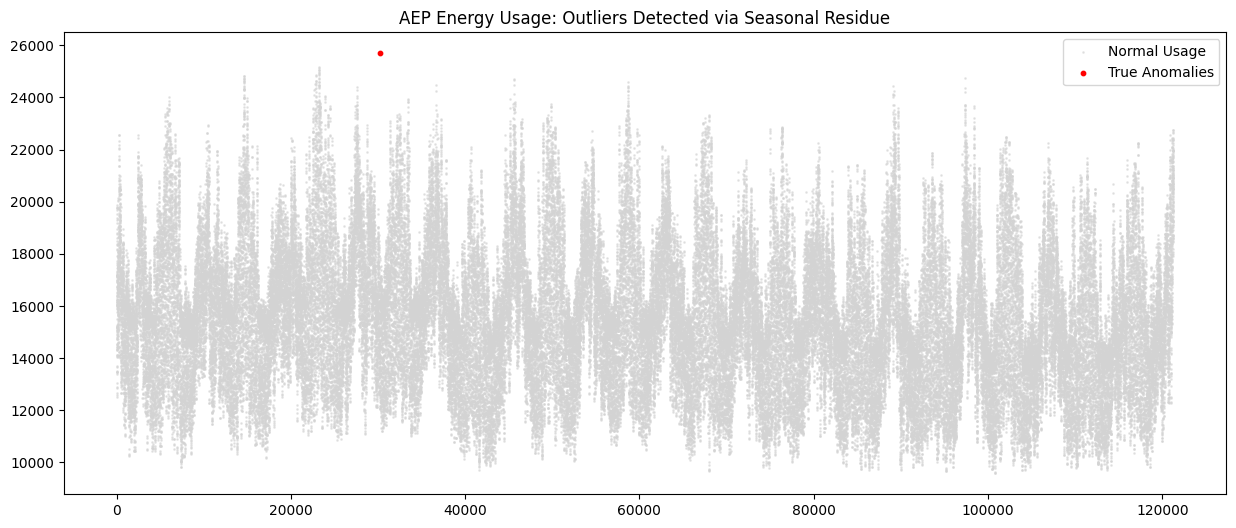

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# --- STEP 1: DECOMPOSE ---
# Period 24 extracts the daily pattern
result = seasonal_decompose(test_data['total_usage'], model='additive', period=24)
test_data['residue'] = result.resid

# Changing period to 168 (24 hours * 7 days)
analysis_weekly = seasonal_decompose(test_data['total_usage'], 
                                     model='additive', 
                                     period=168)

# The residue now represents 'How much did this hour differ from the WEEKLY norm?'
residue_weekly = analysis_weekly.resid



# --- STEP 2: CALCULATE THRESHOLDS ON RESIDUE ---
Q1 = test_data['residue'].quantile(0.25)
Q3 = test_data['residue'].quantile(0.75)
IQR = Q3 - Q1

# Using 3 * IQR on residue is the standard for "Extreme Anomalies"
upper_limit = Q3 + (3 * IQR)
lower_limit = Q1 - (3 * IQR)

# --- STEP 3: CREATE THE OUTLIER DATAFRAME ---
outlier_mask = (test_data['residue'] > upper_limit) | (test_data['residue'] < lower_limit)
outliers = test_data[outlier_mask]

# --- STEP 4: PLOT ---
plt.figure(figsize=(15, 6))

# Plot all normal data in gray
plt.scatter(test_data.index, test_data['total_usage'], color='lightgray', s=1, alpha=0.5, label='Normal Usage')

# Plot outliers in red
plt.scatter(outliers.index, outliers['total_usage'], color='red', s=10, label='True Anomalies')

plt.title('AEP Energy Usage: Outliers Detected via Seasonal Residue')
plt.legend()
plt.show()

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

folder_path = 'electricity-data'
files = glob.glob(os.path.join(folder_path, '*_hourly.csv'))

# Dictionary to store the datetime lists of outliers
outlier_datetimes = {}

for file in files:
    # 1. Load and identify company
    df = pd.read_csv(file)
    company = os.path.basename(file).split('_')[0]
    
    # 2. YOUR CLEANING LOGIC: Sum numeric columns to get total_usage
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    df['total_usage'] = df[numeric_cols].sum(axis=1)
    
    # 3. CONVERT DATETIME (Using your format)
    df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M:%S')
    
    # 4. PREPARE FOR DECOMPOSITION
    # We must set the index and remove duplicates for the math to work
    df = df.drop_duplicates(subset=['Datetime']).set_index('Datetime').sort_index()
    
    # This 'resample' step is the secret sauce—it tells Python the frequency is 1 hour
    # without crashing like .asfreq() does.
    df_resampled = df['total_usage'].resample('1h').mean().ffill()
    
    # 5. RUN SEASONAL DECOMPOSITION (Weekly Period = 168)
    # This will now run because resample defined the frequency
    result = seasonal_decompose(df_resampled, model='additive', period=168)
    residue = result.resid.dropna()
    
    # 6. CALCULATE OUTLIERS ON RESIDUE (Using 3x IQR for strictness)
    q1, q3 = residue.quantile(0.25), residue.quantile(0.75)
    iqr = q3 - q1
    upper, lower = q3 + (3 * iqr), q1 - (3 * iqr)
    
    mask = (residue > upper) | (residue < lower)
    
    # Save the actual datetimes of the outliers for your comparison step later
    outlier_datetimes[company] = residue.index[mask].tolist()
    
    print(f"Company: {company:8} | Total Hours: {len(df_resampled):6} | Outliers: {len(outlier_datetimes[company])}")

print("\nProcessing complete. You now have a dictionary 'outlier_datetimes' with all dates.")

Company: AEP      | Total Hours: 121296 | Outliers: 54
Company: COMED    | Total Hours:  66504 | Outliers: 667
Company: DAYTON   | Total Hours: 121296 | Outliers: 209
Company: DEOK     | Total Hours:  57744 | Outliers: 11
Company: DOM      | Total Hours: 116208 | Outliers: 72
Company: DUQ      | Total Hours: 119088 | Outliers: 545
Company: EKPC     | Total Hours:  45336 | Outliers: 74
Company: FE       | Total Hours:  62880 | Outliers: 265
Company: NI       | Total Hours:  58464 | Outliers: 530

Processing complete. You now have a dictionary 'outlier_datetimes' with all dates.


In [70]:
# 1. Flatten the dictionary into a list of (Timestamp, Company)
flat_list = []
for company, dates in outlier_datetimes.items():
    for dt in dates:
        flat_list.append({'Datetime': dt, 'Company': company})

# 2. Create a DataFrame of all anomalies
df_outliers = pd.DataFrame(flat_list)

# 3. Count how many companies had an outlier at each specific Datetime
# This creates a "Collusion Count"
collusion_counts = df_outliers.groupby('Datetime').size().reset_index(name='Company_Count')

# 4. Filter for events where at least 2 companies "colluded"
shared_events = collusion_counts[collusion_counts['Company_Count'] > 1].sort_values(by='Company_Count', ascending=False)

# 5. Map which companies were involved in the top events
def get_companies(dt):
    return ", ".join(df_outliers[df_outliers['Datetime'] == dt]['Company'].tolist())

# Take the top 10 most "collusive" hours
top_events = shared_events.head(10).copy()
top_events['Involved_Companies'] = top_events['Datetime'].apply(get_companies)

print("Top 10 Systemic Grid Events (Most Companies Reporting Simultaneous Outliers):")
print(top_events[['Datetime', 'Company_Count', 'Involved_Companies']])

Top 10 Systemic Grid Events (Most Companies Reporting Simultaneous Outliers):
                Datetime  Company_Count                 Involved_Companies
1533 2016-09-05 08:00:00              6  AEP, COMED, DAYTON, DEOK, DUQ, FE
964  2012-06-29 15:00:00              6    AEP, DAYTON, DEOK, DOM, DUQ, FE
965  2012-06-29 16:00:00              6    AEP, DAYTON, DEOK, DOM, DUQ, FE
1181 2013-09-10 16:00:00              5        AEP, COMED, DAYTON, DUQ, FE
993  2012-07-07 16:00:00              5        AEP, COMED, DAYTON, DUQ, FE
1180 2013-09-10 15:00:00              5        AEP, COMED, DAYTON, DUQ, FE
1182 2013-09-10 17:00:00              5        AEP, COMED, DAYTON, DUQ, FE
1183 2013-09-10 18:00:00              5        AEP, COMED, DAYTON, DUQ, FE
874  2011-09-02 17:00:00              5        AEP, COMED, DAYTON, DUQ, FE
1534 2016-09-05 09:00:00              5        AEP, COMED, DAYTON, DUQ, FE


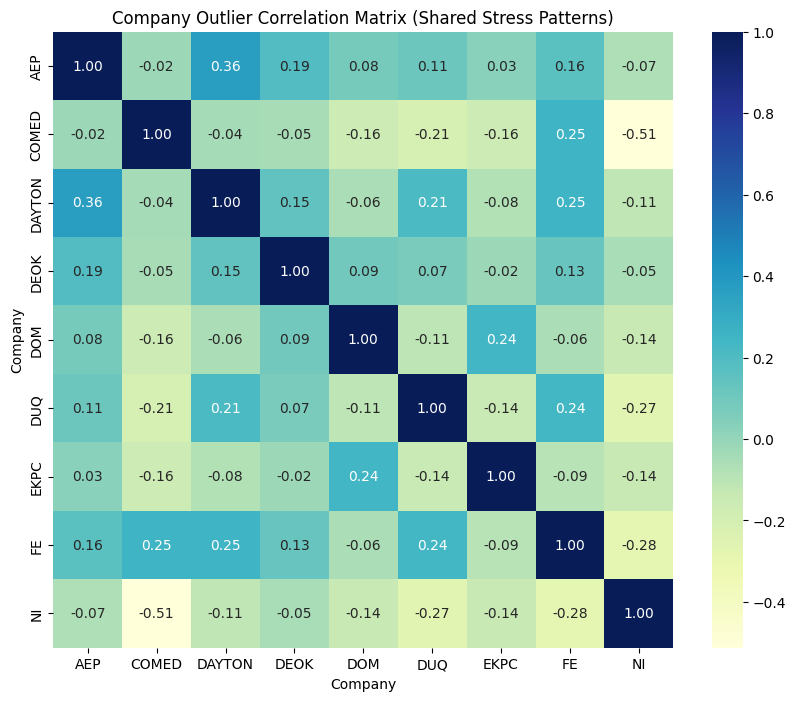

In [71]:
import seaborn as sns

# 1. Create a binary matrix (Rows = Datetime, Cols = Company)
# 1 if it was an outlier for that company at that time, 0 otherwise
pivot_df = df_outliers.assign(val=1).pivot(index='Datetime', columns='Company', values='val').fillna(0)

# 2. Calculate the Correlation between companies' outliers
# This shows which companies "collude" most often
correlation_matrix = pivot_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Company Outlier Correlation Matrix (Shared Stress Patterns)')
plt.show()

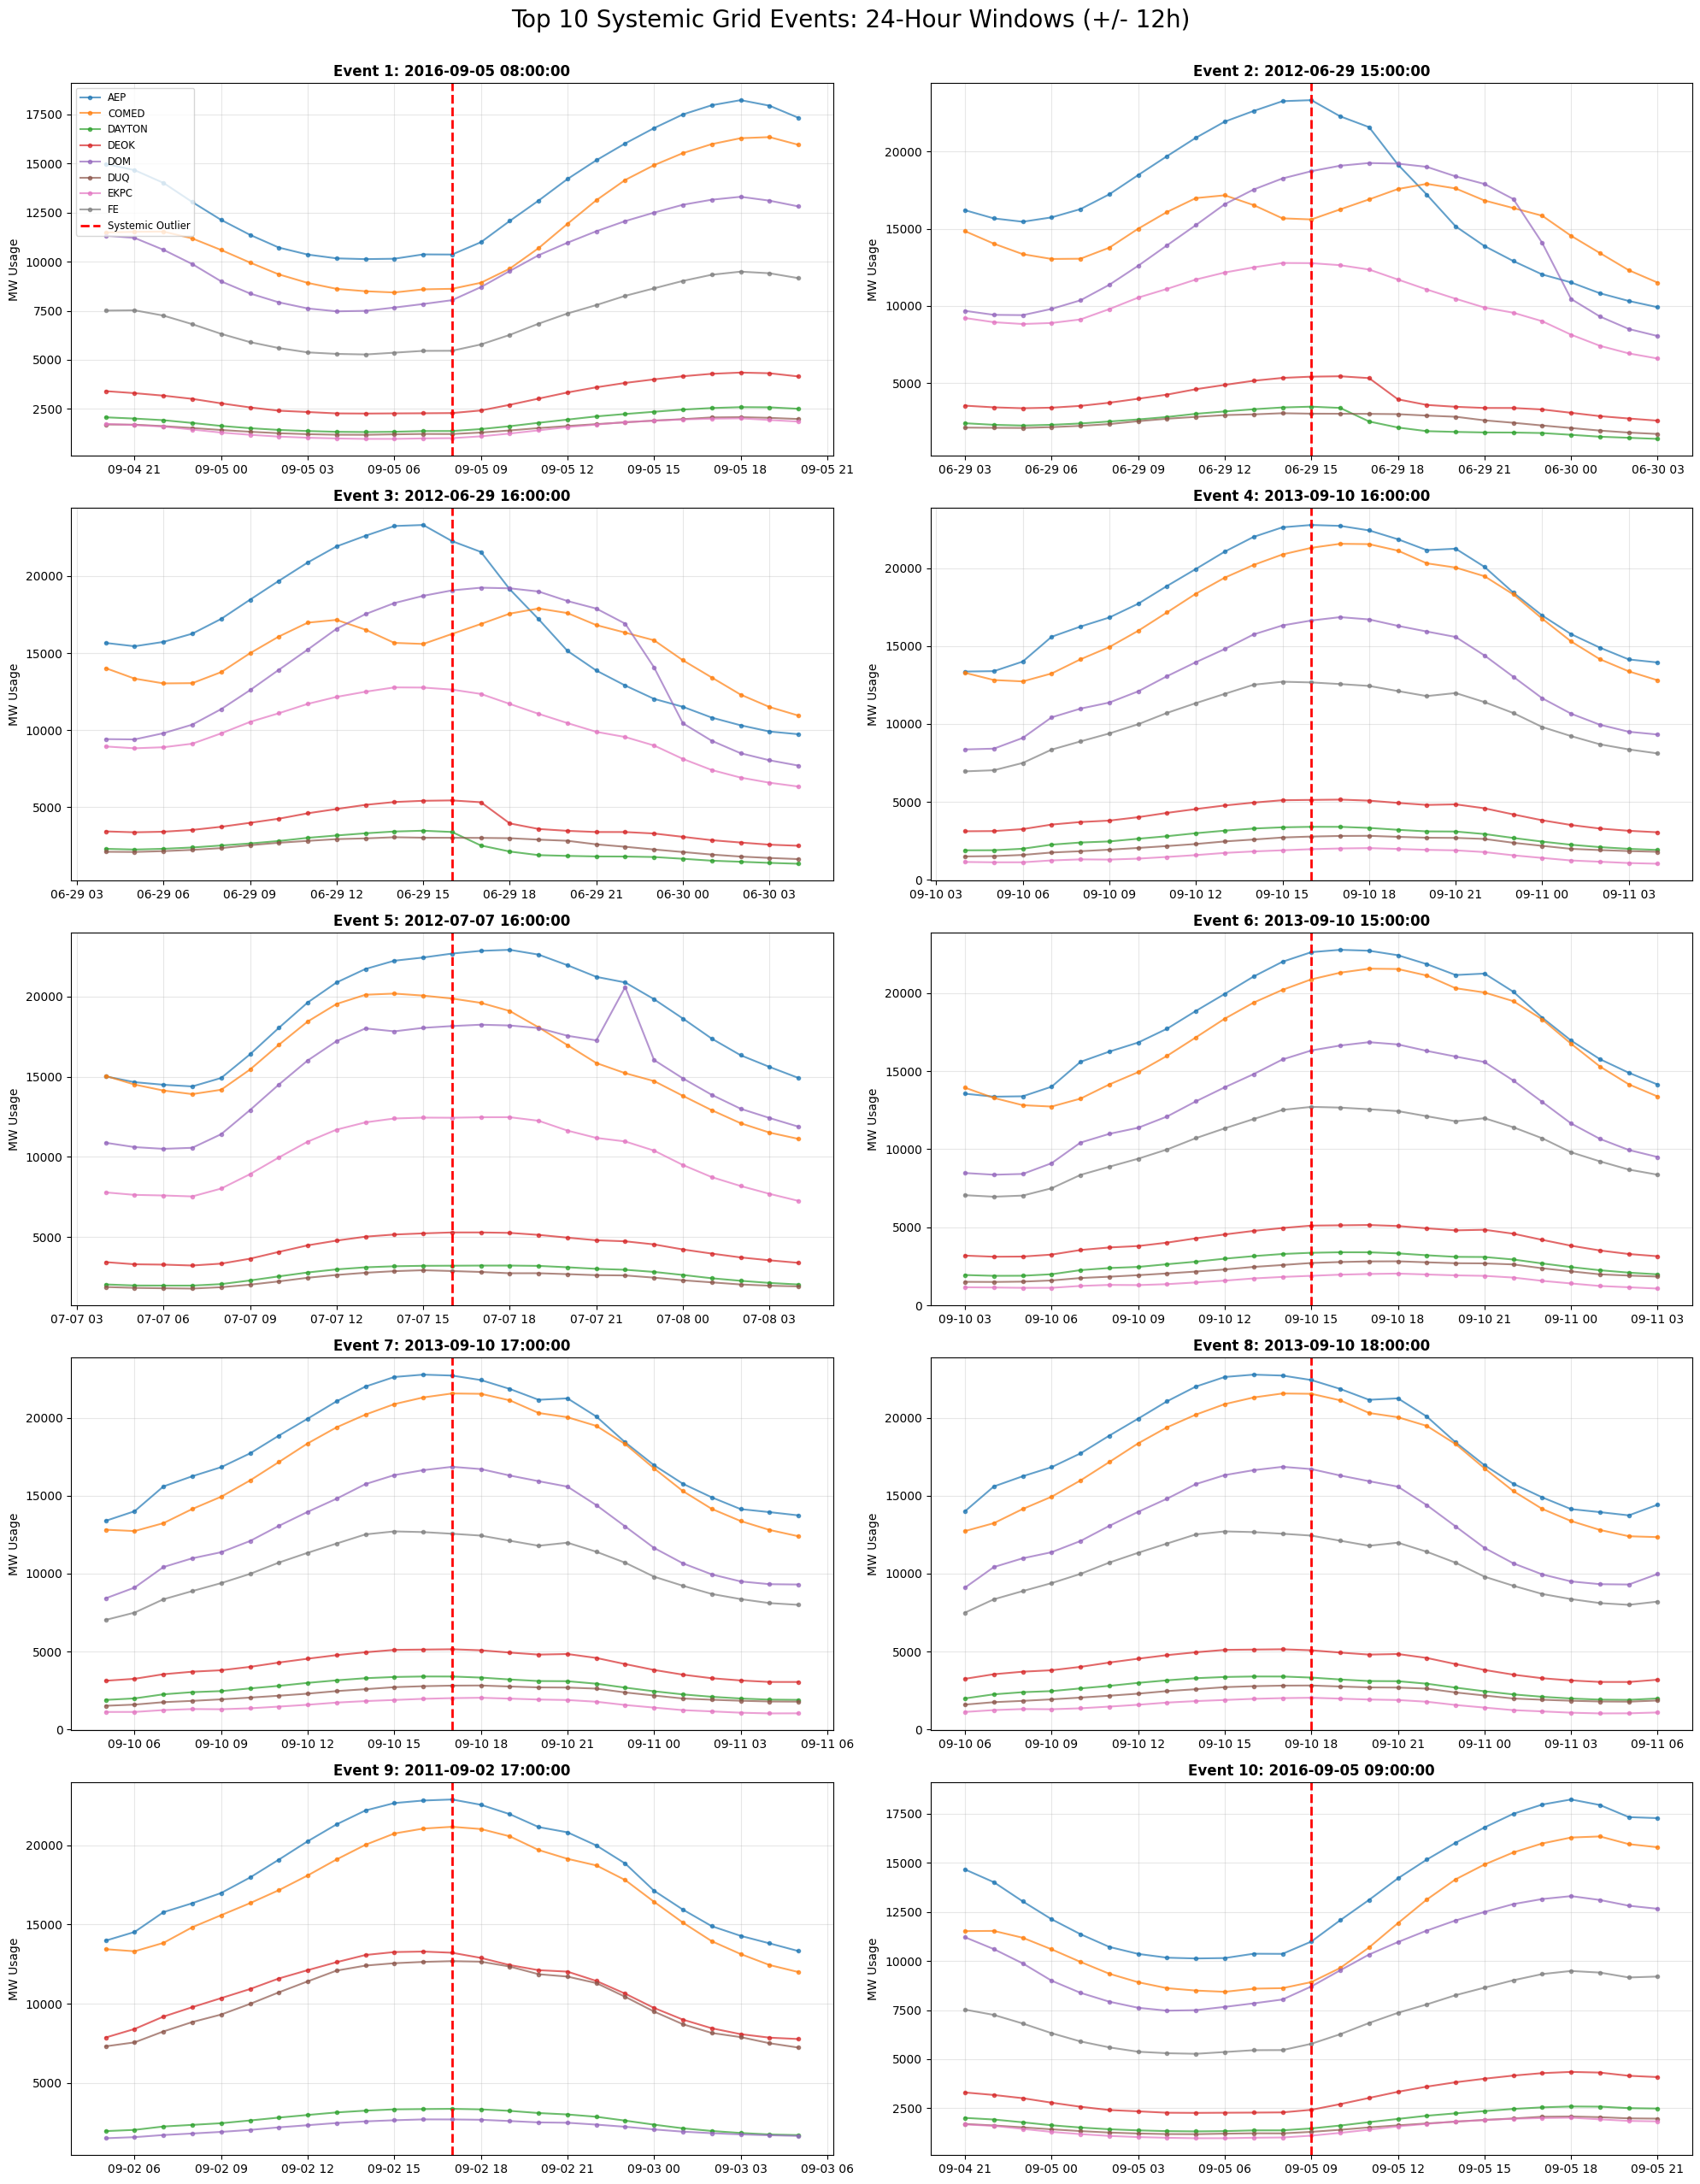

In [72]:
# 1. Prepare the Top 10 Events
# Assuming 'top_events' was generated in the previous step
top_10_list = top_events['Datetime'].tolist()

# 2. Set up a multi-plot figure (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 25))
axes = axes.flatten() # Flatten to 1D array for easy looping

for i, event_time in enumerate(top_10_list):
    # Define the 12-hour window
    start_window = event_time - pd.Timedelta(hours=12)
    end_window = event_time + pd.Timedelta(hours=12)
    
    # Filter the combined_df for this specific window
    window_mask = (combined_df['Datetime'] >= start_window) & (combined_df['Datetime'] <= end_window)
    window_data = combined_df.loc[window_mask]
    
    ax = axes[i]
    
    # Plot each company present in this window
    for company in window_data['Company'].unique():
        company_subset = window_data[window_data['Company'] == company].sort_values('Datetime')
        ax.plot(company_subset['Datetime'], company_subset['total_usage'], label=company, marker='o', markersize=3, alpha=0.7)

    # 3. Highlight the exact "Collusion Hour"
    ax.axvline(event_time, color='red', linestyle='--', linewidth=2, label='Systemic Outlier')
    
    # Formatting each subplot
    ax.set_title(f"Event {i+1}: {event_time}", fontweight='bold')
    ax.set_ylabel("MW Usage")
    ax.grid(True, alpha=0.3)
    
    # Only show legend for the first plot to keep it clean
    if i == 0:
        ax.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.suptitle("Top 10 Systemic Grid Events: 24-Hour Windows (+/- 12h)", fontsize=20, y=1.02)
plt.show()